In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')


In [45]:
%store -r df
df = df

%store -r numeric_cols
numeric_cols = numeric_cols

%store -r cat_cols
cat_cols = cat_cols

# Descriptive Analysis

## Numerical Data

In [46]:
# analyze descriptiive statistics for quantiative variables
def kde_plot(col):
    plt.figure(figsize=(12, 3))

    sns.histplot(df[col], kde=True, bins=22, alpha=0.25, stat='density', edgecolor=None)
    sns.kdeplot(df[col], linewidth=5)

    mean = df[col].mean()
    median = df[col].median()

    plt.axvline(mean, color='black', linestyle='dashed', label=f"Mean")
    plt.axvline(median, color='green', linestyle='solid', label=f"Median")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    sns.despine(left=True)

    plt.show()

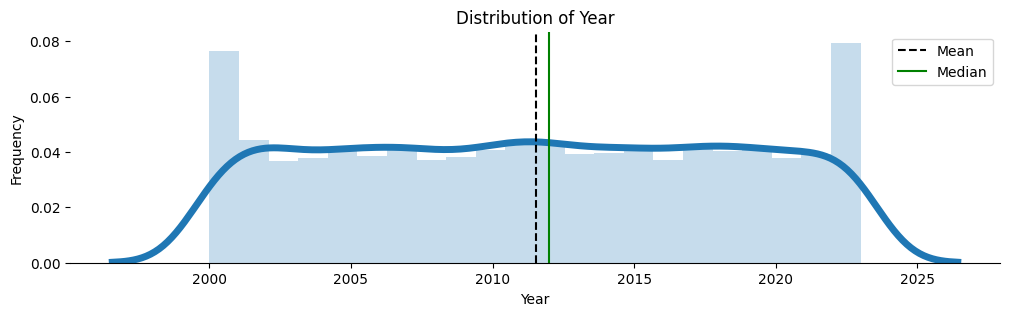

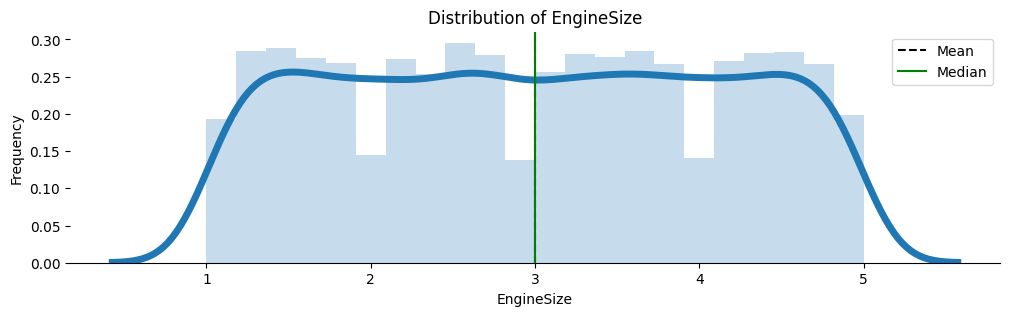

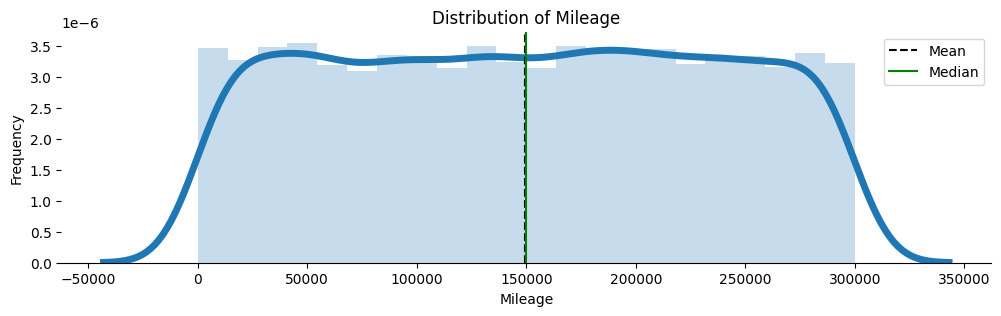

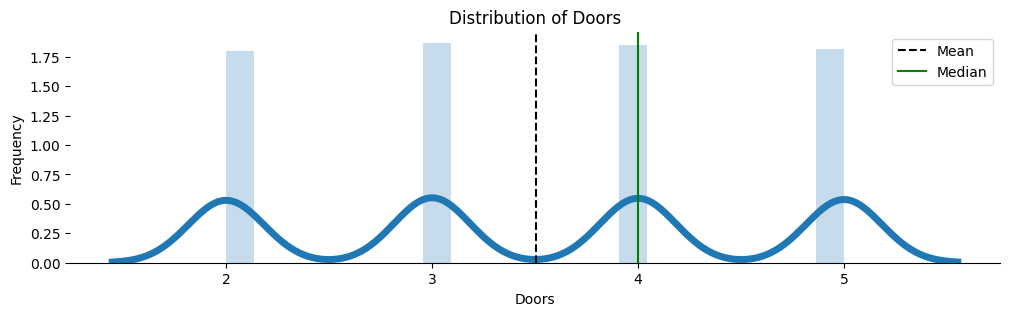

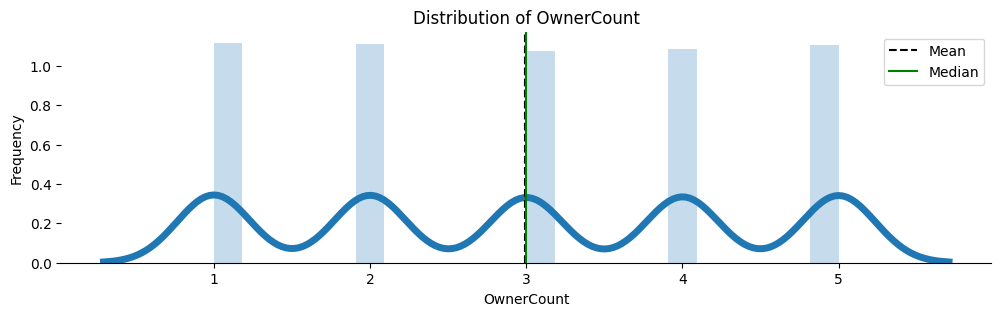

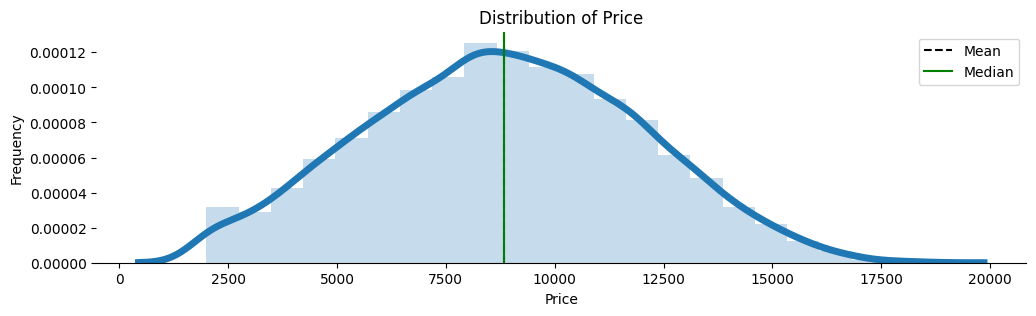

In [47]:
for col in df[numeric_cols].columns:
    kde_plot(col)

## Categorical Data

In [48]:
# find the most common category in each column
for col in df[cat_cols].columns:
    print(f"{col} - most common: {df[col].mode()[0]}")

Brand - most common: Audi
Model - most common: Accord
Fuel - most common: Electric
Transmission - most common: Manual


# Correlation Analysis

## Numerical Data

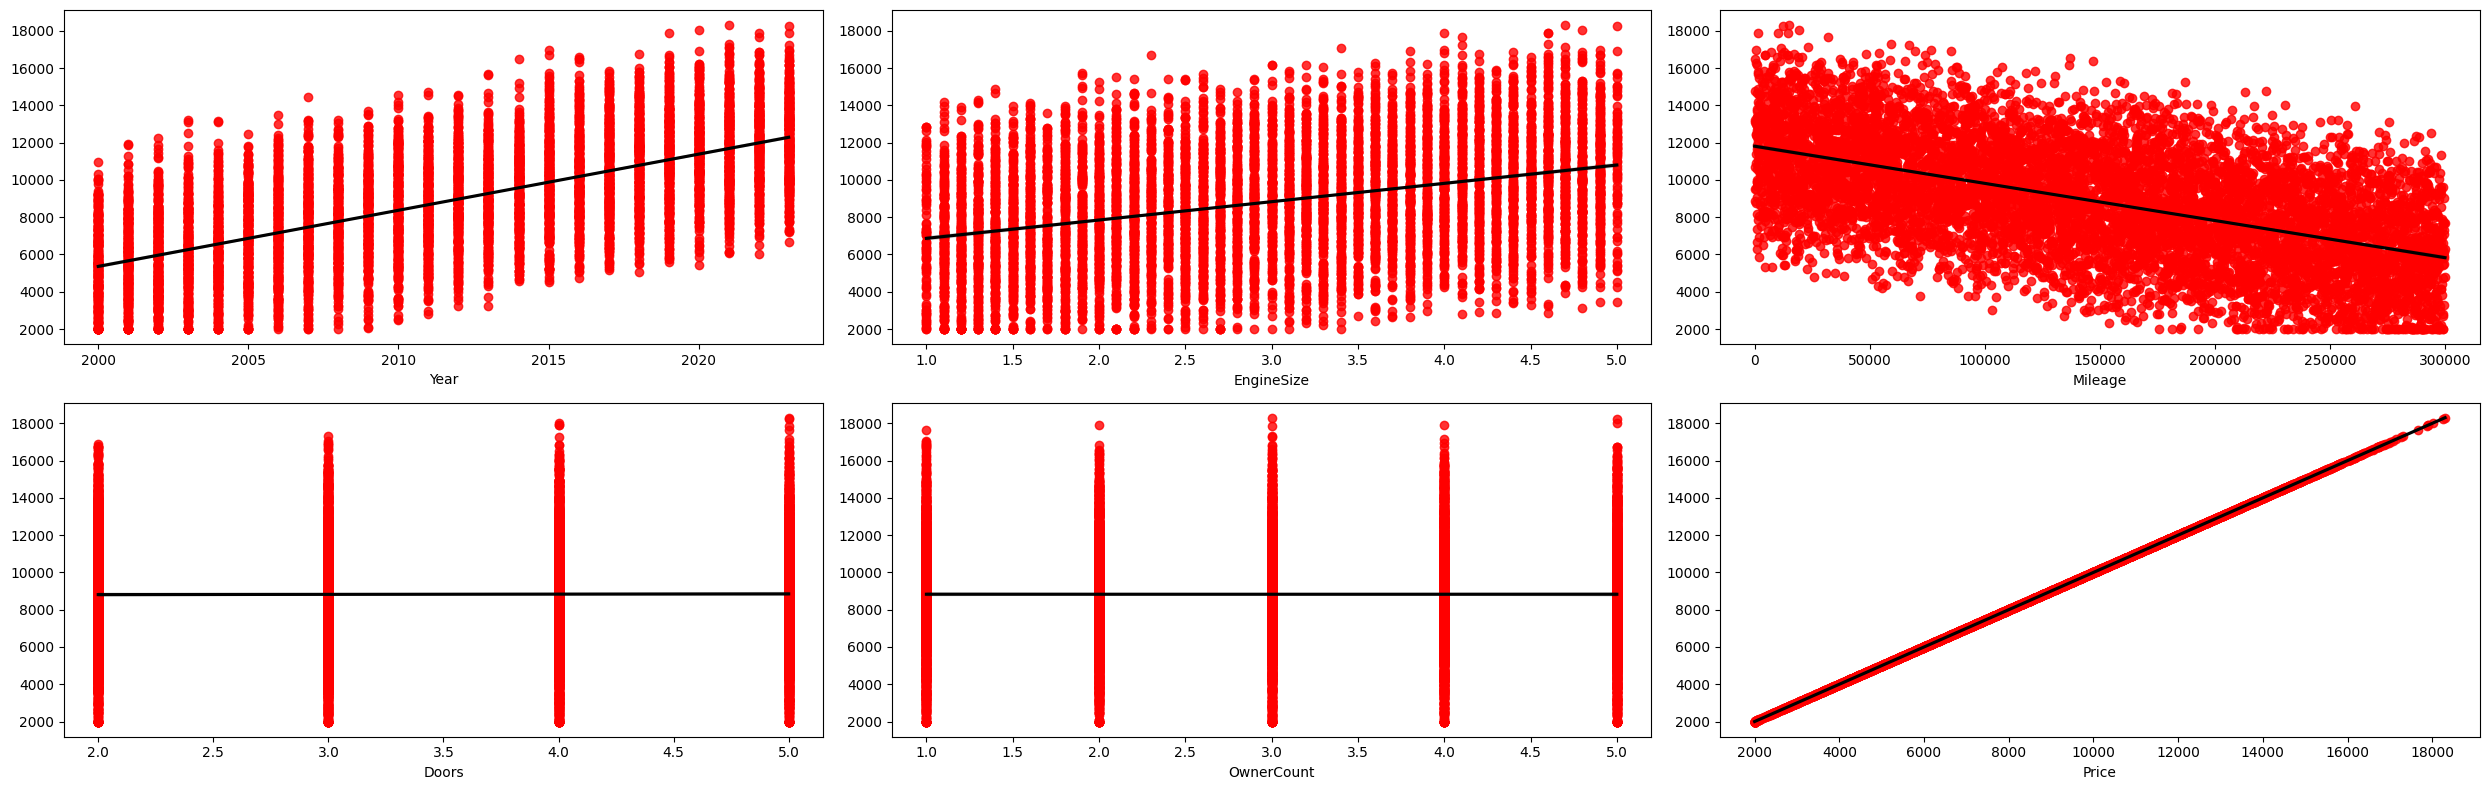

In [49]:
# numerical data (Pearson)
fig, axes = plt.subplots(2, 3, figsize=(25, 8))
axes = axes.ravel()

for idx, value in enumerate(numeric_cols):
    sns.regplot(data=df, 
                x=value,
                y='Price',
                ax=axes[idx],
                scatter_kws={"color": "red"},
                line_kws={"color": "black"})
    axes[idx].set_xlabel(value)
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.show()

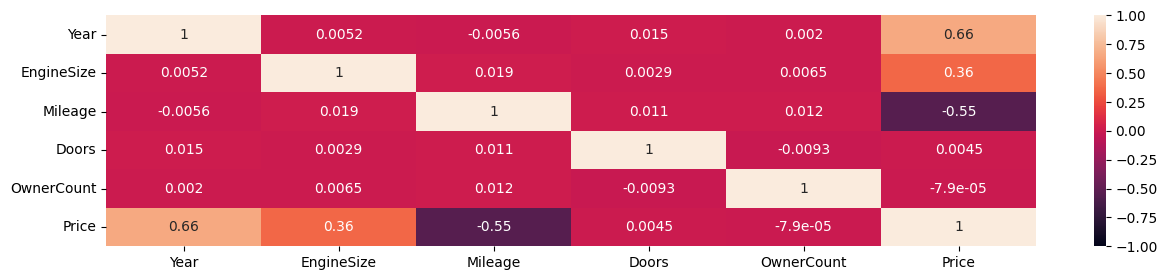

In [50]:
# heatmap for correlation between features
pearson_cor = df[numeric_cols].corr(method='pearson')
plt.figure(figsize=(15,3))

sns.heatmap(pearson_cor,
            vmin= -1,
            vmax= 1,
            annot= True)
plt.show()

## Categorical Data

In [51]:
# we conduct ANOVA test to compare the differences between means
for col in cat_cols:
    formula = 'Price ~ {}'.format(col)
    model = ols(formula, data=df).fit()
    anova = sm.stats.anova_lm(model, typ=2)
    p_value = anova.iloc[0, 3]

    print('p-value: Price ~ {}: {}'. format(col, p_value))

p-value: Price ~ Brand: 0.18317562683906
p-value: Price ~ Model: 0.5977964773757738
p-value: Price ~ Fuel: 1.1608569649094296e-129
p-value: Price ~ Transmission: 6.731887149603138e-116


In [52]:
# most impact label in each category
def mean_pairwise(col):
    mean_df_pair = df.groupby(col)['Price'].mean()
    mean_df_pair = pd.DataFrame(mean_df_pair)
    mean_df_pair = mean_df_pair.sort_values(by=['Price'], ascending=False)

    return mean_df_pair.head()

for col in cat_cols:
    print(mean_pairwise(col))
    print("============")

                  Price
Brand                  
Chevrolet   9018.451815
Audi        8931.886016
Volkswagen  8901.128019
Mercedes    8892.547554
Kia         8885.963731
               Price
Model               
Tiguan   9146.532423
Impala   9094.073944
Equinox  9093.704453
Q5       9028.094406
Corolla  8995.060377
                 Price
Fuel                  
Electric  10061.022662
Hybrid     9094.456689
Diesel     8091.958829
Petrol     8017.726901
                      Price
Transmission               
Automatic       9954.639456
Manual          8338.461027
Semi-Automatic  8204.673971
